# Exp 17 — Кривые обучения GAT

Читает `<model>.history.json` и `<model>.config.json`, которые сохраняет `12_train.py`.

Структура history: `{"train_loss": [...], "val_loss": [...], "lr": [...]}`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

MODEL_TAG = "bge-m3"
GRAPH_SUBDIR = "v17_views"
LOSS = "ntxent"  # "ntxent" → пустой суффикс, "bce" → "_bce"

suffix = "_bce" if LOSS == "bce" else ""
base = Path("../../output") / MODEL_TAG / f"{GRAPH_SUBDIR}_gat{suffix}_model"
history_path = base.with_suffix(".history.json")
config_path = base.with_suffix(".config.json")

print("History:", history_path, "exists:", history_path.exists())
print("Config: ", config_path, "exists:", config_path.exists())

History: ../../output/bge-m3/v17_views_gat_model.history.json exists: True
Config:  ../../output/bge-m3/v17_views_gat_model.config.json exists: True


In [2]:
history = json.loads(history_path.read_text())
config = json.loads(config_path.read_text()) if config_path.exists() else {}

print("Эпох:", len(history.get("train_loss", [])))
print("Метрики:", list(history.keys()))
print("\nКонфиг модели:")
for k, v in config.items():
    print(f"  {k}: {v}")

Эпох: 38
Метрики: ['train_loss', 'val_loss', 'lr']

Конфиг модели:
  row_dim: 1024
  token_dim: 1024
  col_dim: 1024
  hidden_dim: 1024
  edge_dim: 1024
  output_dim: 1024
  num_gnn_layers: 2
  num_heads: 4
  dropout: 0.3
  attention_dropout: 0.1
  bidirectional: True
  use_input_projection: False
  graph_subdir: v17_views
  model_tag: bge-m3


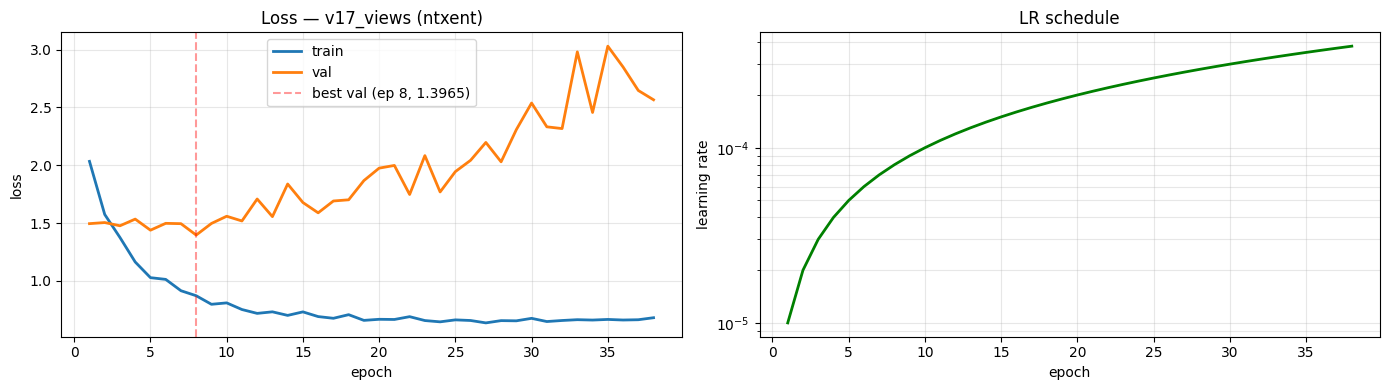

In [3]:
train = history.get("train_loss", [])
val = history.get("val_loss", [])
lr = history.get("lr", [])

n_panels = 2 if lr else 1
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 4))
if n_panels == 1:
    axes = [axes]

ax = axes[0]
epochs = np.arange(1, len(train) + 1)
ax.plot(epochs, train, label="train", lw=2)
if val:
    ax.plot(np.arange(1, len(val) + 1), val, label="val", lw=2)
    best_ep = int(np.argmin(val)) + 1
    ax.axvline(best_ep, color="red", ls="--", alpha=0.4,
               label=f"best val (ep {best_ep}, {min(val):.4f})")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title(f"Loss — {GRAPH_SUBDIR} ({LOSS})")
ax.legend()
ax.grid(alpha=0.3)

if lr:
    ax = axes[1]
    ax.plot(np.arange(1, len(lr) + 1), lr, color="green", lw=2)
    ax.set_xlabel("epoch")
    ax.set_ylabel("learning rate")
    ax.set_title("LR schedule")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Числовая сводка

In [4]:
if val:
    best_ep = int(np.argmin(val))
    print(f"Лучший val_loss: {val[best_ep]:.4f} на эпохе {best_ep + 1}")
    print(f"Финальный val_loss: {val[-1]:.4f} на эпохе {len(val)}")
if train:
    print(f"Финальный train_loss: {train[-1]:.4f}")
    print(f"Gap (train→val) на последней эпохе: "
          f"{(val[-1] - train[-1]) if val else 'нет val':.4f}" if val else "")

Лучший val_loss: 1.3965 на эпохе 8
Финальный val_loss: 2.5657 на эпохе 38
Финальный train_loss: 0.6820
Gap (train→val) на последней эпохе: 1.8837


## Сравнить несколько ранов (опционально)

Если запустишь и ntxent, и bce, или с разными графами — добавь сюда пути.

In [ ]:
runs = {
    # "ntxent": Path("../../output/bge-m3/v17_views_gat_model.history.json"),
    # "bce":    Path("../../output/bge-m3/v17_views_gat_bce_model.history.json"),
}

if runs:
    fig, ax = plt.subplots(figsize=(9, 5))
    for name, path in runs.items():
        if not path.exists():
            print(f"skip {name}: {path} нет")
            continue
        h = json.loads(path.read_text())
        v = h.get("val_loss", [])
        ax.plot(np.arange(1, len(v) + 1), v, label=name, lw=2)
    ax.set_xlabel("epoch")
    ax.set_ylabel("val loss")
    ax.legend(); ax.grid(alpha=0.3)
    plt.show()